###  Supplementary Figure 1: Arm A during (23rd Jan 2025)

In [13]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [14]:
import marsilea as ma
import marsilea.plotter as mp

In [15]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [16]:
## read in data

arm = 'ArmA_2024/'
log_data = 'CN_during/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) #combined since it  has both pre and during data

In [17]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None)) 
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 

In [18]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(414418, 31)
(414418, 1)
(414418, 2)


In [19]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[    19   3189 146576  19024  28831   2150   1817  21182     78   1040
    118   8232  15604     49     36     32   3091   3860   8050   4004
  45137   1868   2815  18460  79156]


In [20]:
unique_ts, counts_ts = np.unique(count_matrix[:,8], return_counts=True)
print(unique_ts)
len(unique_ts)

[ 48.  55.  58.  71.  76.  80.  82.  90.  92.  96.  98. 104. 109. 110.
 115. 120. 121. 122. 123. 124. 127. 133.]


22

(0.0, 13.0)

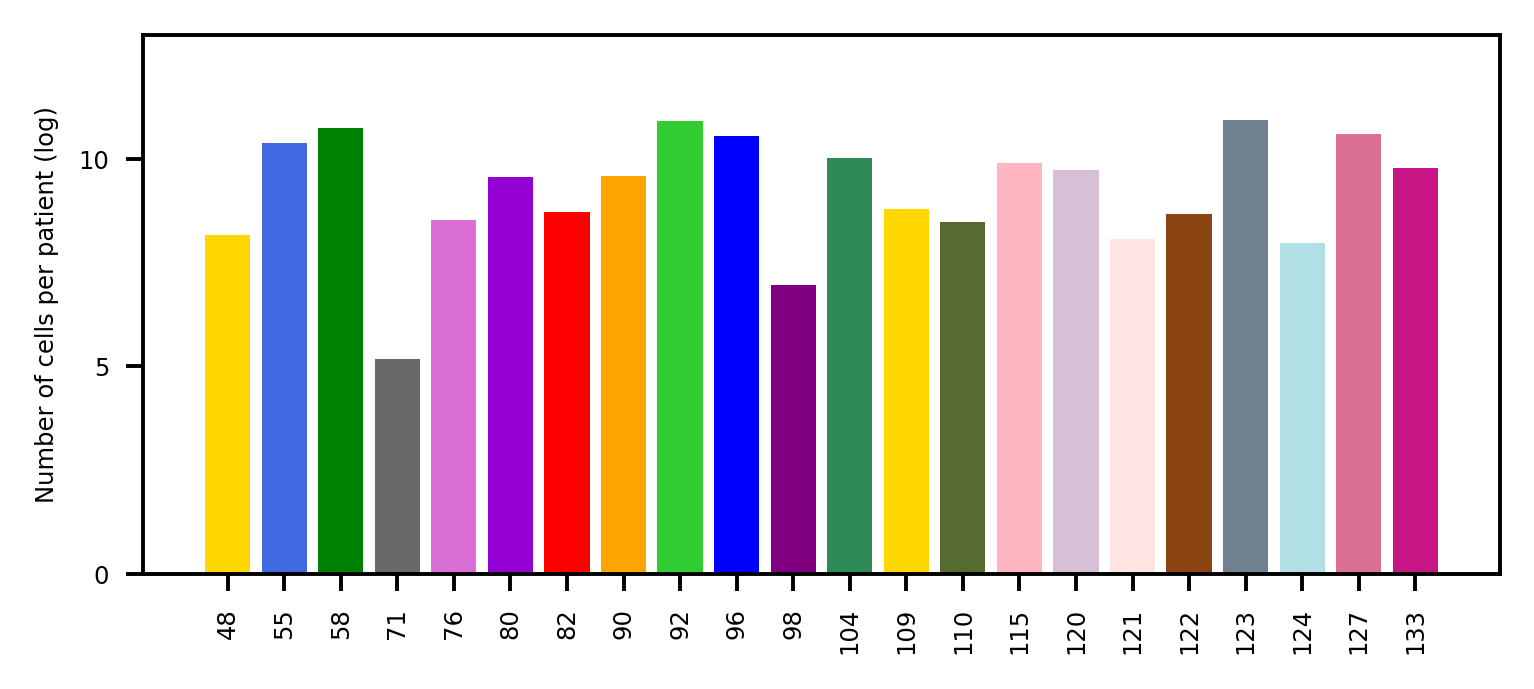

In [21]:
## plot the sizes
N= len(unique_ts)
ind = np.arange(N)
plt.figure(figsize=(5,2), dpi=350)
x=np.arange(N) #[0,1,2,3,4]

y=np.log(counts_ts)#/tot_cells)

for h in range(N):
    plt.bar(x[h], y[h], color=colours_30[h+1])
    
plt.xticks(ind, np.int64(unique_ts),rotation = 90,fontsize=5)
plt.yticks(fontsize=5)
plt.ylabel('Number of cells per patient (log)',fontsize=5)
plt.ylim(0,13)

